In [2]:
data = pd.read_csv("../../Data/dataset_split/train/train.csv")

In [ ]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.version.cuda)
print(torch.cuda.get_device_name(0))

2.7.1+cu118
True
11.8
NVIDIA GeForce GTX 1650


## **Exploring data at first glimpse (EDA)**

In [3]:
data.isna().sum()

image_id                        0
patient_id                      0
camera                          0
patient_age                  4346
comorbidities                6619
diabetes_time_y             11470
insuline                    11634
patient_sex                     0
exam_eye                        0
diabetes                        0
nationality                     0
optic_disc                      0
vessels                         0
macula                          0
DR_SDRG                         0
DR_ICDR                         0
focus                           0
Illuminaton                     0
image_field                     0
artifacts                       0
diabetic_retinopathy            0
macular_edema                   0
scar                            0
nevus                           0
amd                             0
vascular_occlusion              0
hypertensive_retinopathy        0
drusens                         0
hemorrhage                      0
retinal_detach

In [4]:
data.duplicated().sum()

np.int64(0)

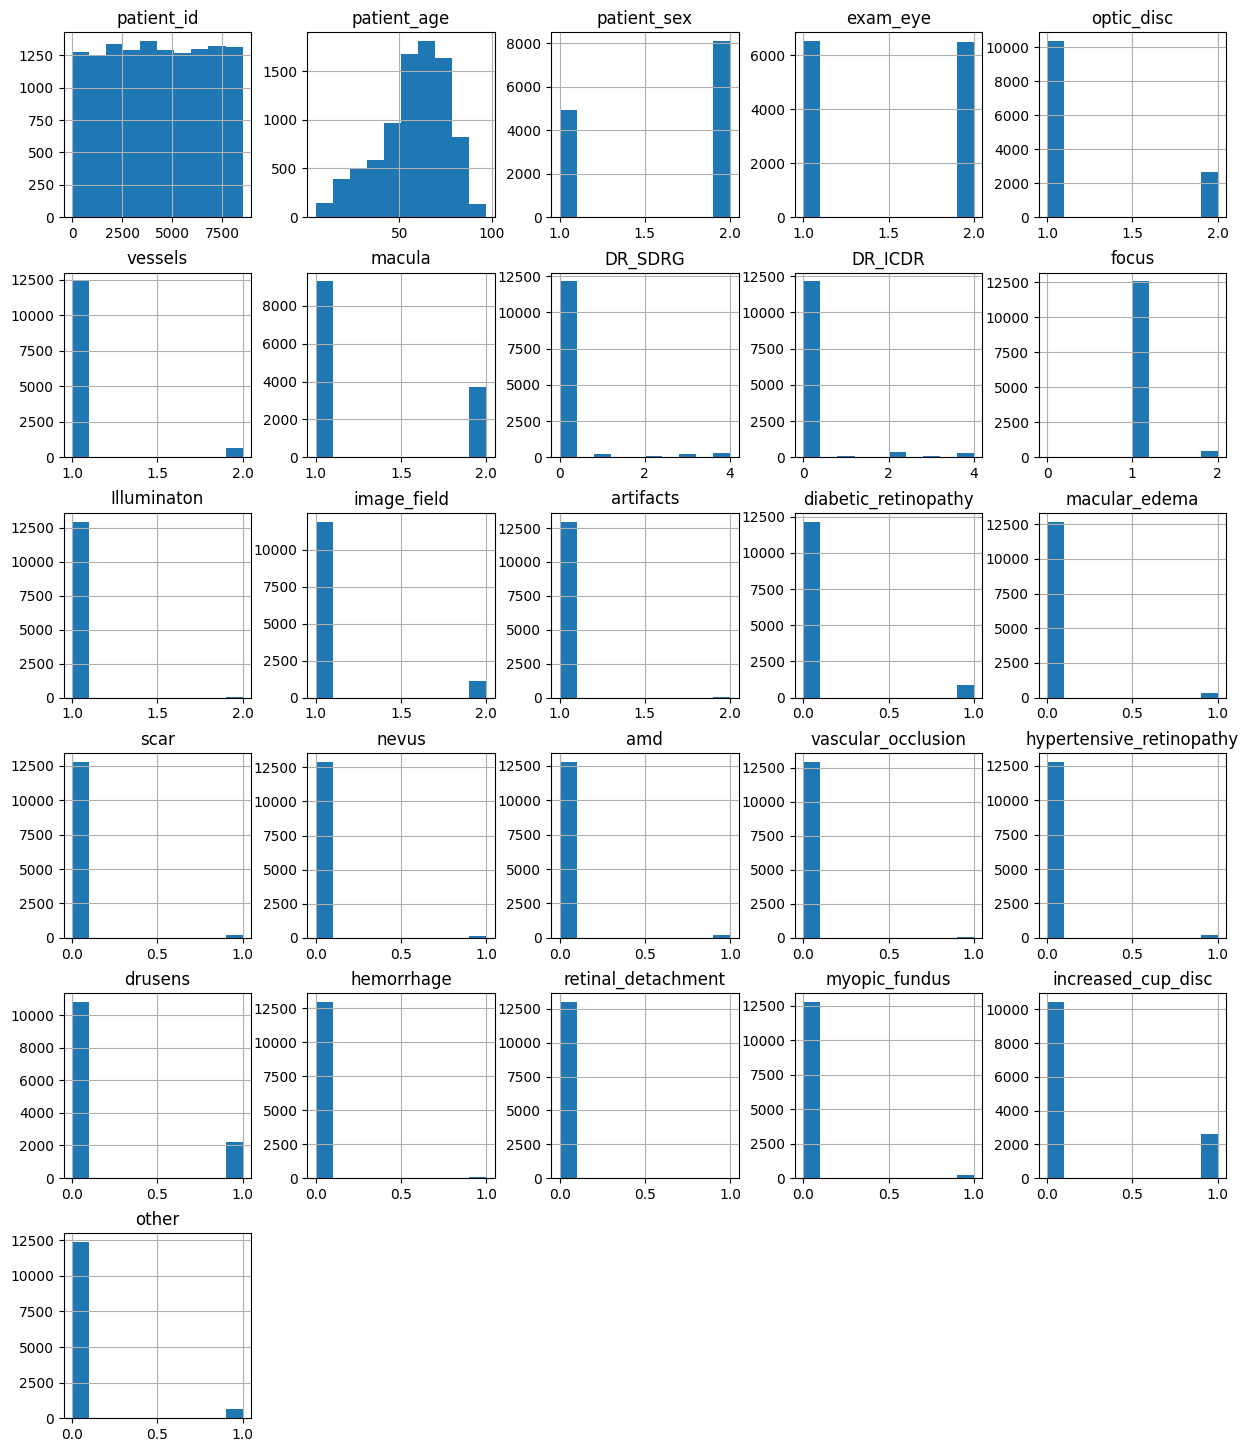

In [4]:
data.hist(figsize=(15,18))
plt.show()

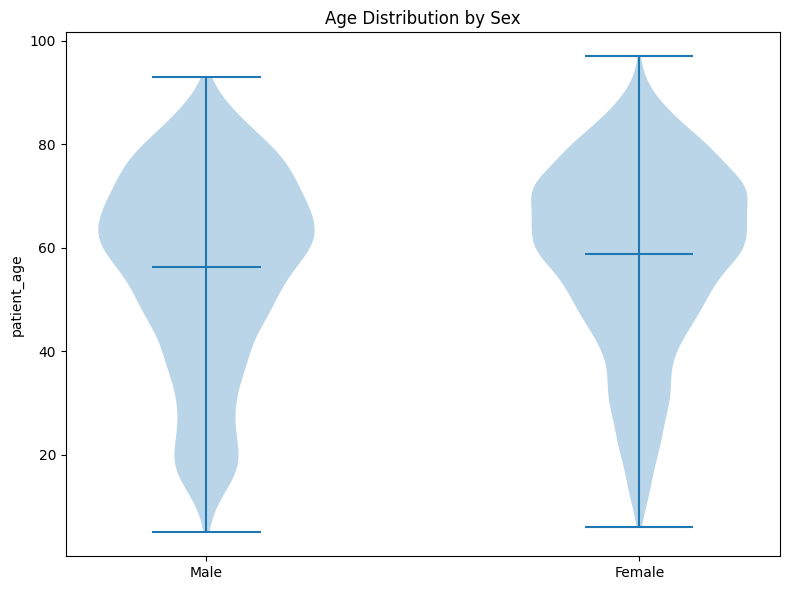

In [6]:
male_age = data[data['patient_sex'] == 1]['patient_age'].dropna()
female_age = data[data['patient_sex'] == 2]['patient_age'].dropna()

plt.figure(figsize=(8,6))
plt.violinplot([male_age, female_age], showmeans=True)

plt.xticks([1, 2], ['Male', 'Female'])
plt.ylabel('patient_age')
plt.title('Age Distribution by Sex')
plt.tight_layout()
plt.show()


In [7]:
data['patient_sex'].unique()
# patient_sex: Enumerated values: 1 for male and 2 for female.

array([1, 2])

In [17]:
data2 = data.copy()

In [9]:
data2.drop(columns=['image_id','patient_id'],inplace = True)

In [10]:
count = 1
for col in data2.columns:
    print(f"{count}. Unique Values for [ {col} ] is : ",data2[col].unique(),'\n')
    count+=1

1. Unique Values for [ camera ] is :  <StringArray>
['Canon CR', 'NIKON NF5050']
Length: 2, dtype: str 

2. Unique Values for [ patient_age ] is :  [48. 18. 22. 23. 14. 20. 28. 37. 21. 16. 24. 26. 19. 17. 13. 27. 39. 25.
 30. 15. 29. 57. 44. 38. 47. 42. 10. 59. 32. 66. 82. 87. 80. 41. 76. 71.
 73. 83. 45. 61. 55. 75. 81. 72. 64. 46. 74. 65. 31. 33. 53. 50. 51. 49.
 63. 62. 52. 70. 79. 60. 78. 54. 56. 77. 58. 85. 86. 84. 69. 11. 68. nan
  9. 91. 36. 90. 67. 88.  7. 35. 40. 43. 89. 34. 12.  8. 95. 97.  6. 93.
 94.  5. 92.] 

3. Unique Values for [ comorbidities ] is :  <StringArray>
[                                     'diabetes1',
                        'diabetes1, hypertension',
                         'diabetes, hypertension',
                                   'dyslipidemia',
                                   'hypertension',
                                              nan,
                                              '0',
                                'hyperthyroidism',
    

In [11]:
def show_missing(data2):
    """
    Visualizes and reports missing values in a Pandas DataFrame.

    Parameters:
    - data2 (DataFrame): The input Pandas DataFrame to check for missing values.

    Returns:
    None

    This function performs the following tasks:
    1. Displays a missing data matrix plot to visualize the location of missing values in the DataFrame.
    2. Prints the percentage of missing values in each column with missing data.
    3. Creates a bar plot to visualize the percentage of missing values in each column.

    Example usage:
    show_missing(data2)
    """
    
    # Visualize the percentage of missing data using a bar plot
    msno.matrix(data2)
    
    
    # Print the percentage of missing values in the columns with missing
    features_with_nan = [features for features in data2.columns if data2[features].isnull().sum()>=1]
    print(f'{len(features_with_nan)} columns with missing values detected:')

    for features in features_with_nan:
        print(features , np.round(data2[features].isnull().mean(),4) * 100 , '% missing values')

    
    # Create a bar plot to visualize missing values
    # Calculate the percentage of missing data in each column
    missing_percentage = data2.isnull().mean() * 100
    missing_percentage
    
    plt.figure(figsize=(10, 6))
    missing_percentage.plot(kind='bar', color='skyblue')
    plt.title('Percentage of Missing Values per Column')
    plt.xlabel('Columns')
    plt.ylabel('Percentage Missing')
    plt.xticks(rotation=90)
    plt.tight_layout()
    
    plt.show()

4 columns with missing values detected:
patient_age 33.39 % missing values
comorbidities 50.86000000000001 % missing values
diabetes_time_y 88.13 % missing values
insuline 89.39 % missing values


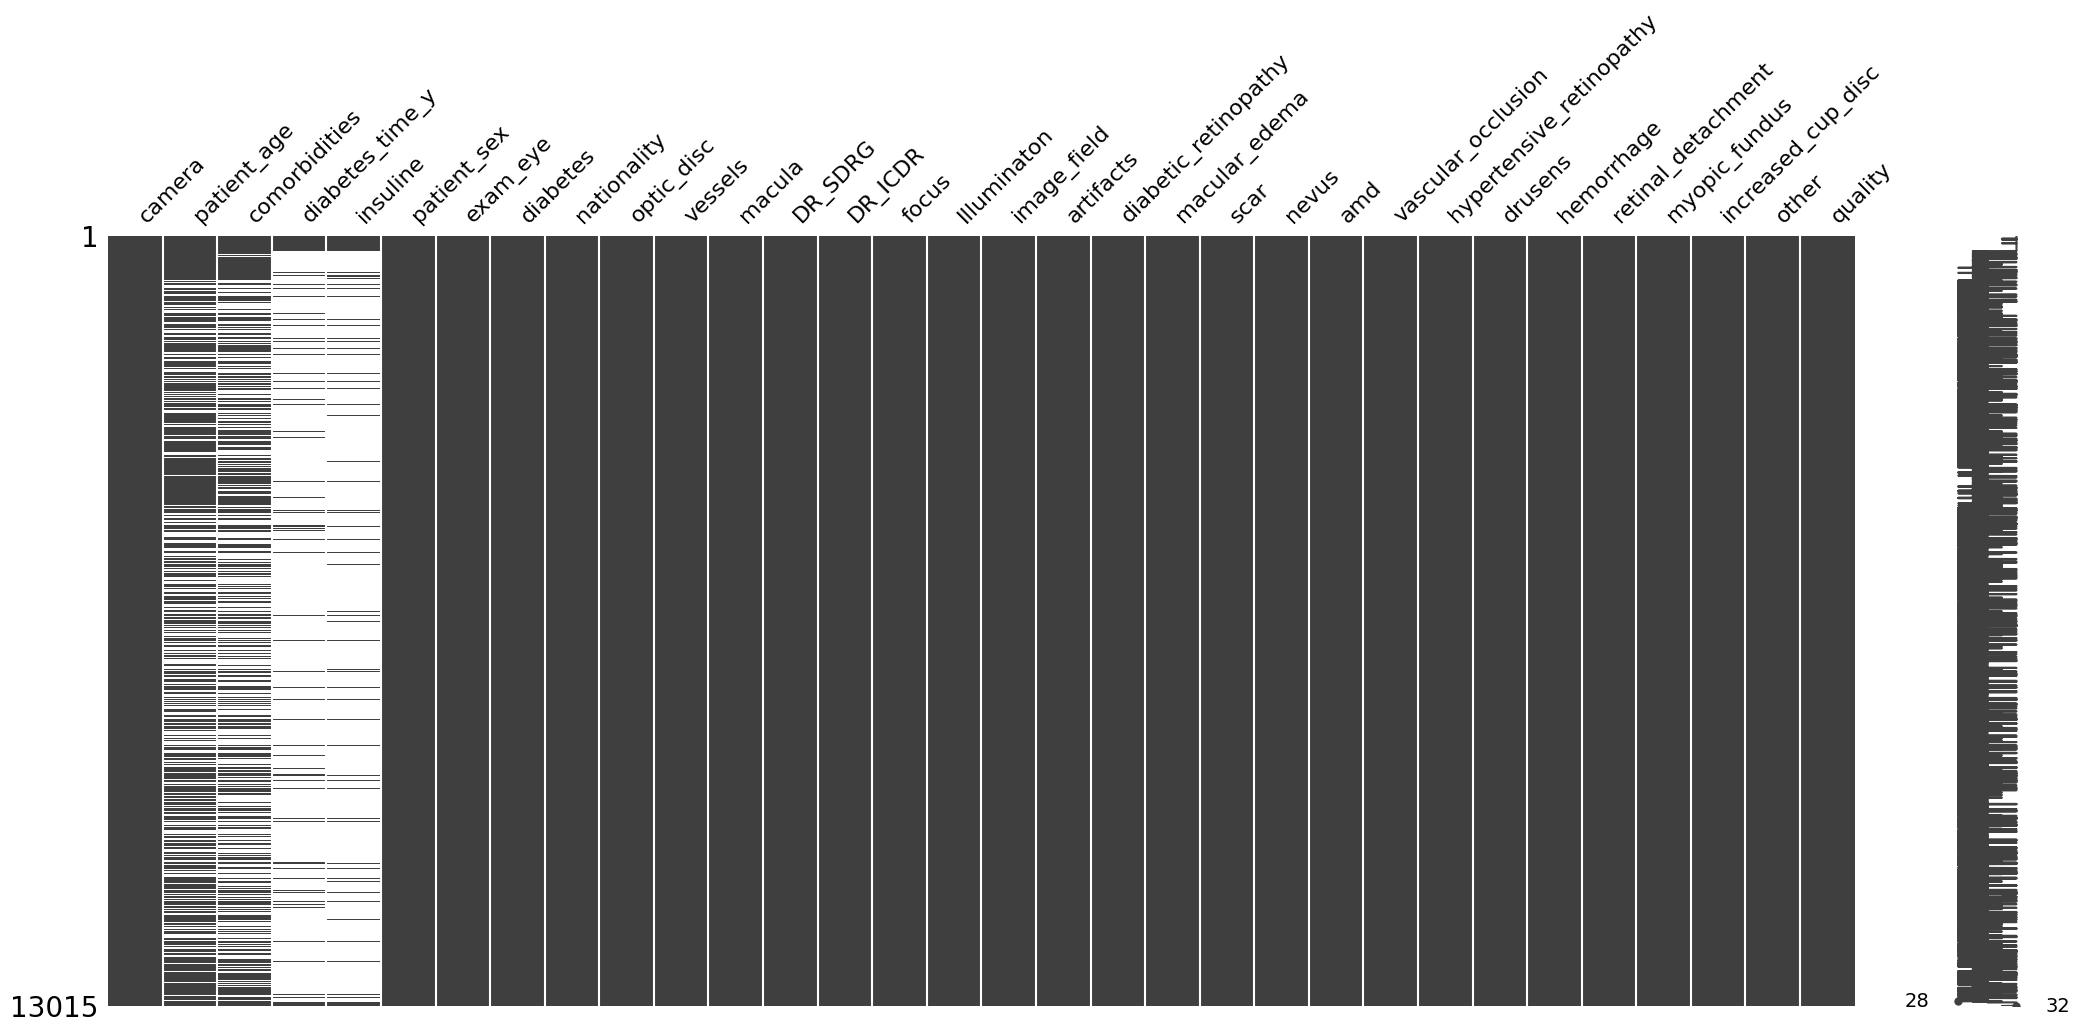

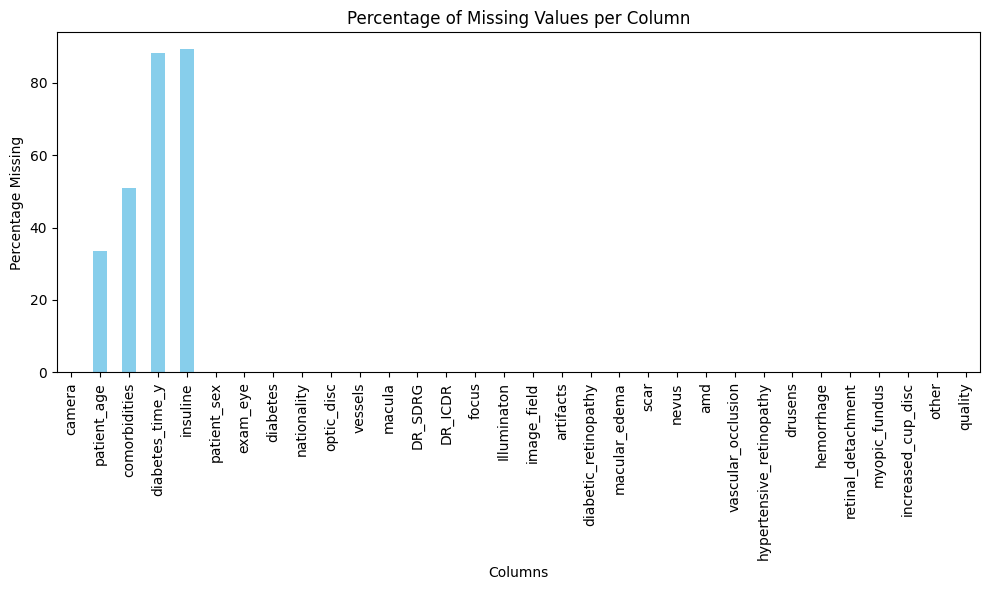

In [12]:
show_missing(data2)

In [13]:
# Categorical Data:
def plot_categorical_column(data2, column, save=True):
    """
    Generate pie charts and bar plots to visualize categorical columns in a Pandas DataFrame.

    Parameters:
    data2 (pandas.DataFrame): The DataFrame containing the categorical data.
    n (int, optional): The maximum number of unique values allowed in a column for it to be considered categorical.
                       Default is 10.
    categorical_columns (list of str, optional): A list of column names to be visualized. If not specified,
                                                 the function will automatically identify categorical columns.

    This function iterates through the specified or automatically identified categorical columns in the DataFrame
    and creates two plots for each column: a pie chart illustrating the distribution of categories as percentages
    and a bar plot showing the count of each category.

    The function utilizes the 'plot_categorical_column' function to generate the individual plots for each column.

    Args:
    data2 (pandas.DataFrame): The DataFrame containing the categorical data.
    n (int, optional): The maximum number of unique values allowed in a column for it to be considered categorical.
    categorical_columns (list of str, optional): A list of column names to be visualized.

    Returns:
    None
    """
    
    
    values = data2[column].value_counts()

    print(data2[column].value_counts(normalize=True))
    print('')
    
    if column == 'patient_sex':
        column = 'Patient Sex'

    # Plot a pie chart with improved quality
    plt.figure(figsize=(10, 5))
    
    plt.subplot(121, aspect='equal')
    explode = [0.1] * len(values)  # Explode a slice for emphasis
    colors = plt.cm.Paired(range(len(values)))

    plt.pie(values, labels=values.index, autopct='%1.1f%%', startangle=140, 
            pctdistance=0.85, explode=explode, colors=colors)
    plt.title(f'Distribution of Column {column}')
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

    # Plot a bar chart with improved quality
    plt.subplot(122)
    values.plot(kind='bar', color='skyblue')
    plt.title(f'Distribution of Column {column}')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.5)
    if save:
        os.makedirs('Profile', exist_ok=True)
        plt.savefig(f'Profile/Plots {column}')
    
    plt.show()

In [14]:
data2.info()

<class 'pandas.DataFrame'>
RangeIndex: 13015 entries, 0 to 13014
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   camera                    13015 non-null  str    
 1   patient_age               8669 non-null   float64
 2   comorbidities             6396 non-null   str    
 3   diabetes_time_y           1545 non-null   str    
 4   insuline                  1381 non-null   str    
 5   patient_sex               13015 non-null  int64  
 6   exam_eye                  13015 non-null  int64  
 7   diabetes                  13015 non-null  str    
 8   nationality               13015 non-null  str    
 9   optic_disc                13015 non-null  int64  
 10  vessels                   13015 non-null  int64  
 11  macula                    13015 non-null  int64  
 12  DR_SDRG                   13015 non-null  int64  
 13  DR_ICDR                   13015 non-null  int64  
 14  focus            

In [15]:
import os

patient_sex
2    0.621975
1    0.378025
Name: proportion, dtype: float64



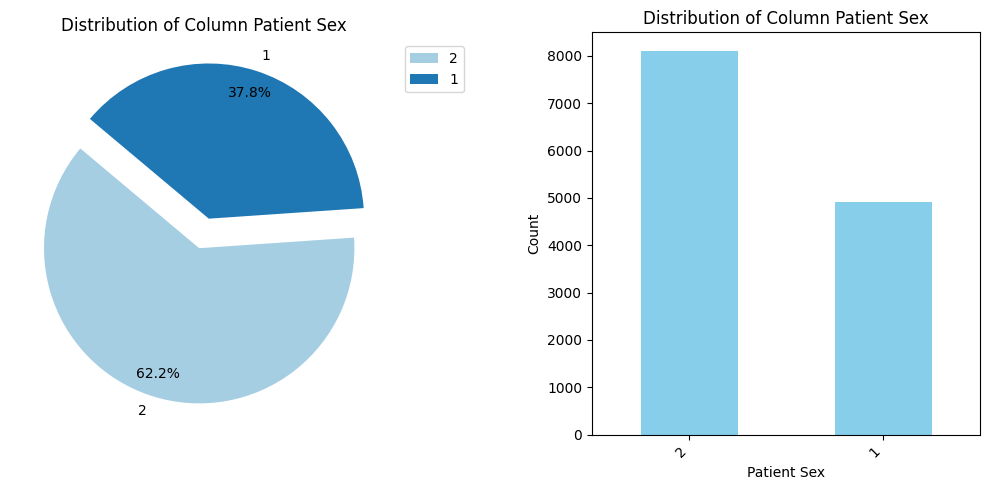

exam_eye
1    0.501729
2    0.498271
Name: proportion, dtype: float64



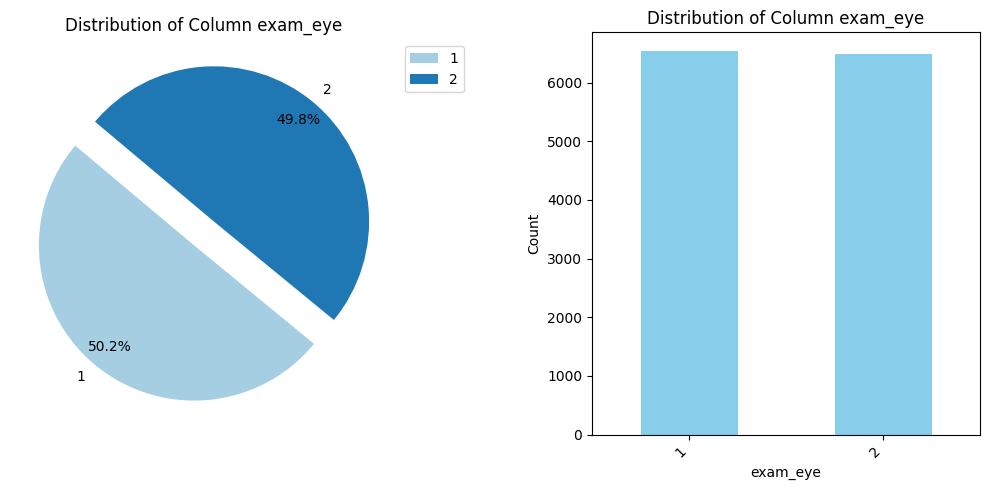

optic_disc
1    0.796005
2    0.203995
Name: proportion, dtype: float64



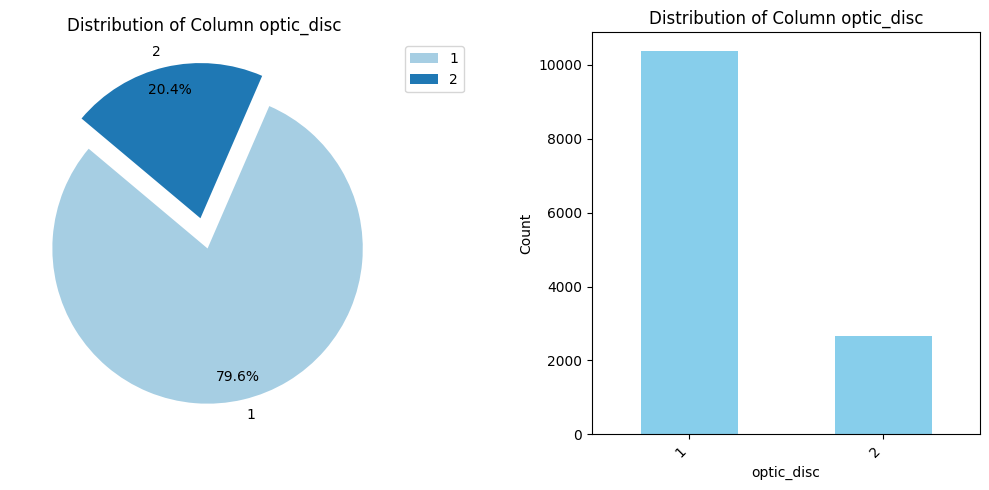

vessels
1    0.951594
2    0.048406
Name: proportion, dtype: float64



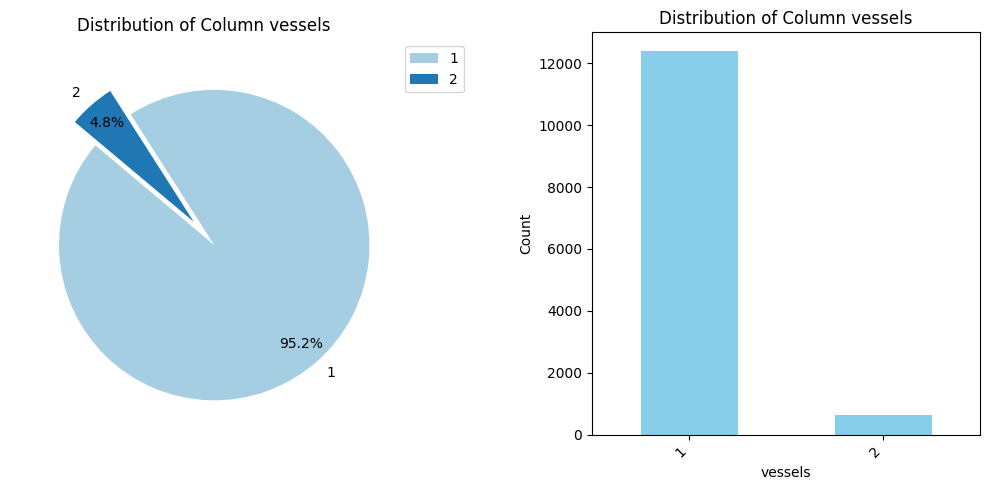

macula
1    0.713484
2    0.286516
Name: proportion, dtype: float64



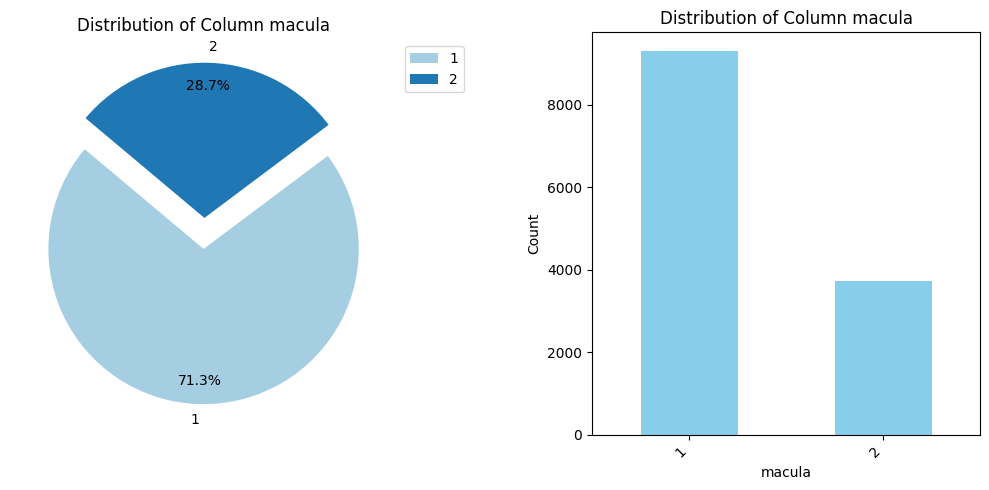

DR_SDRG
0    0.933769
4    0.024818
1    0.016750
3    0.016750
2    0.007914
Name: proportion, dtype: float64



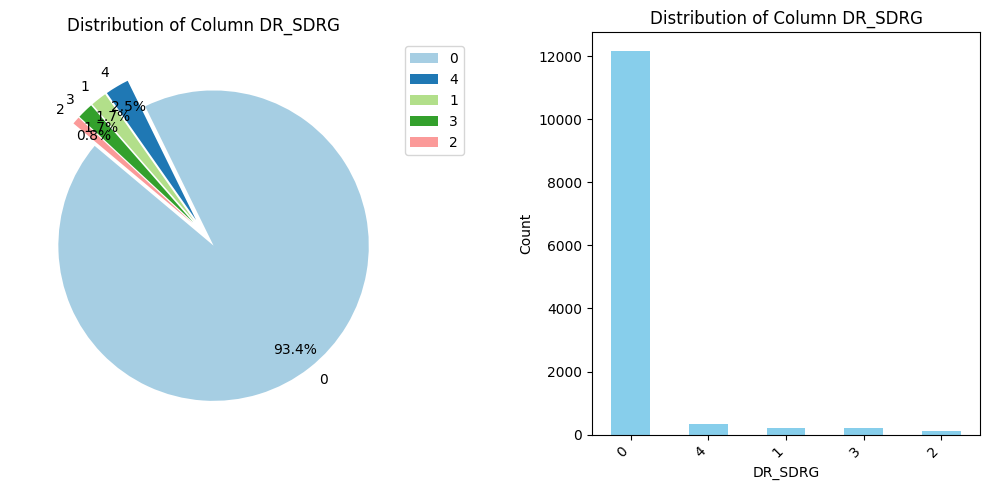

DR_ICDR
0    0.933615
2    0.027430
4    0.024357
1    0.009527
3    0.005071
Name: proportion, dtype: float64



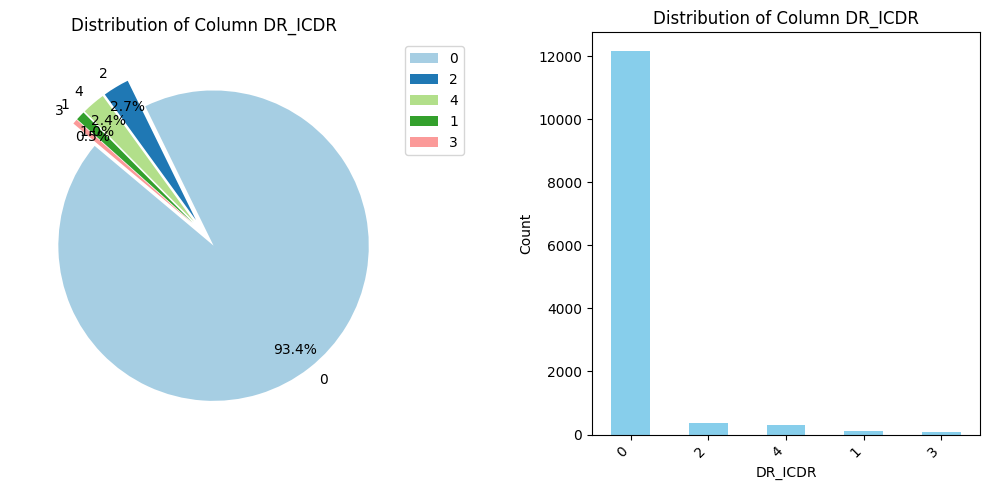

focus
1    0.966347
2    0.033500
0    0.000154
Name: proportion, dtype: float64



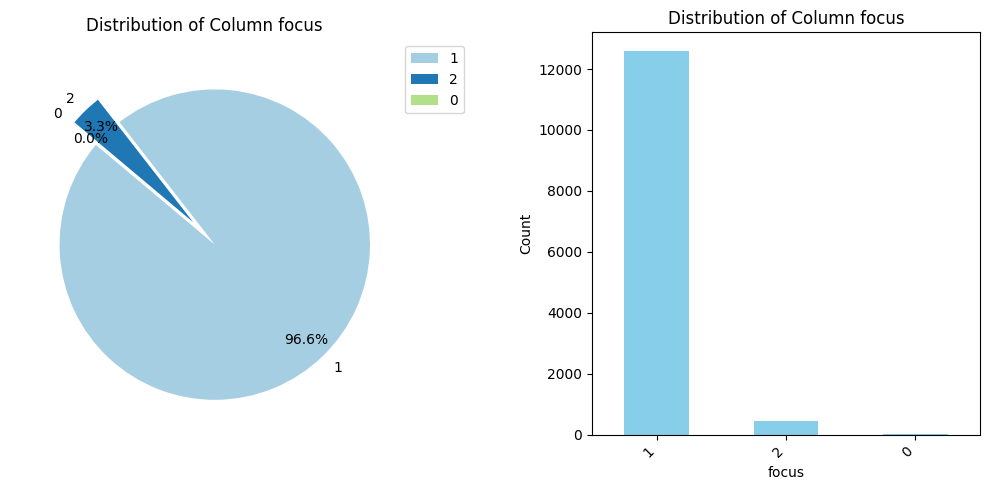

Illuminaton
1    0.994852
2    0.005148
Name: proportion, dtype: float64



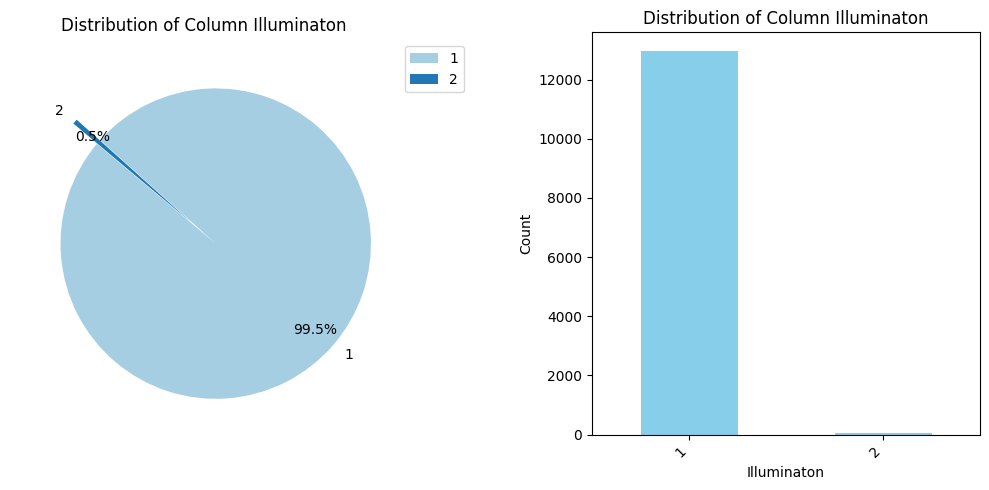

image_field
1    0.913484
2    0.086516
Name: proportion, dtype: float64



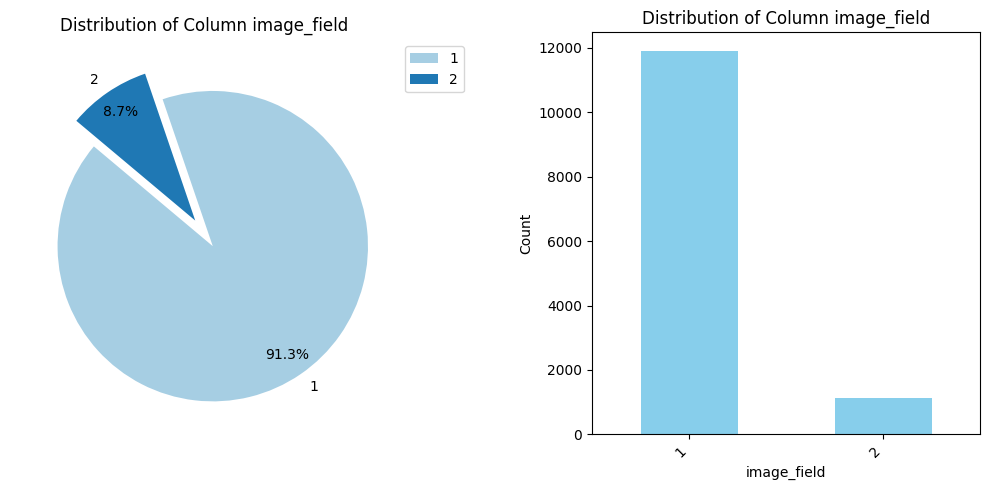

artifacts
1    0.996619
2    0.003381
Name: proportion, dtype: float64



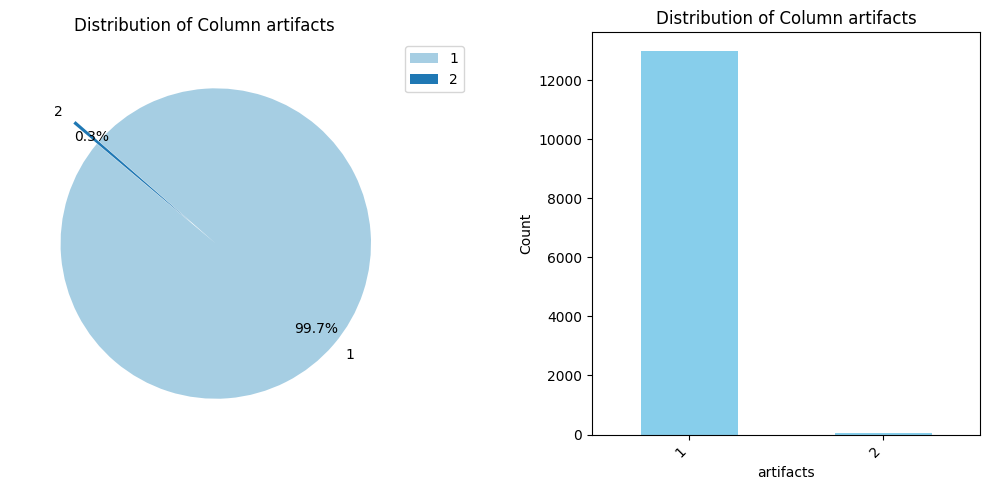

diabetic_retinopathy
0    0.93423
1    0.06577
Name: proportion, dtype: float64



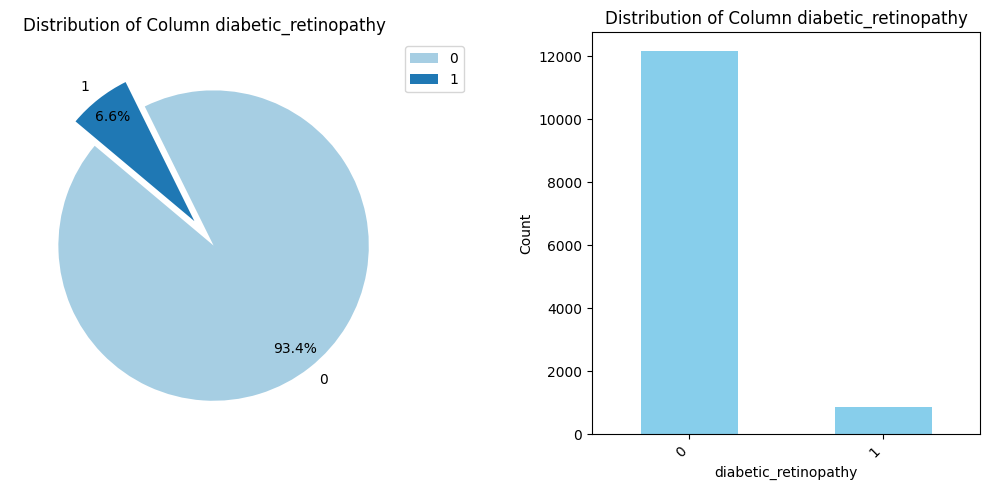

macular_edema
0    0.975336
1    0.024664
Name: proportion, dtype: float64



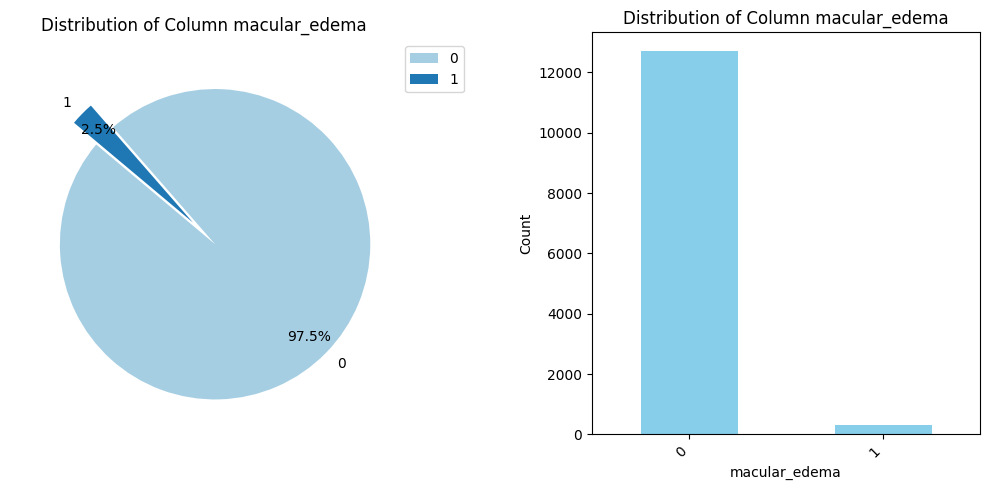

scar
0    0.982482
1    0.017518
Name: proportion, dtype: float64



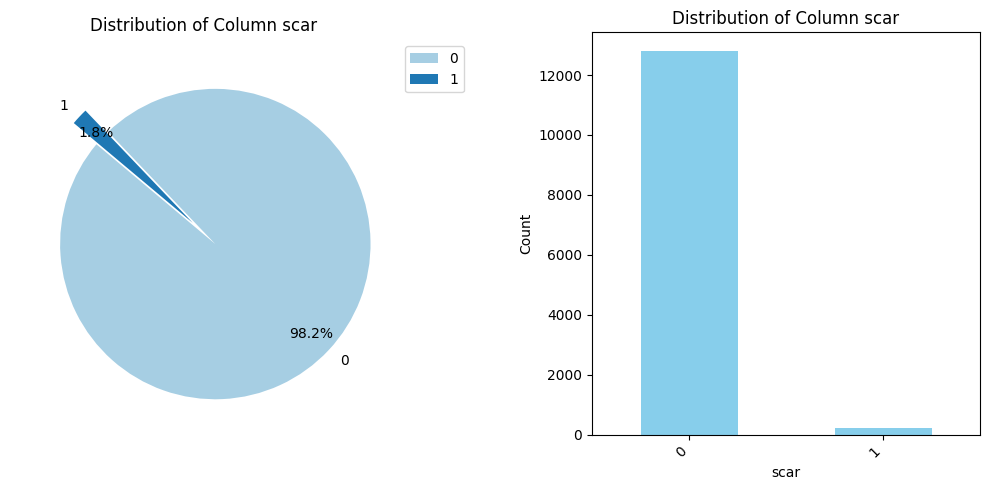

nevus
0    0.991856
1    0.008144
Name: proportion, dtype: float64



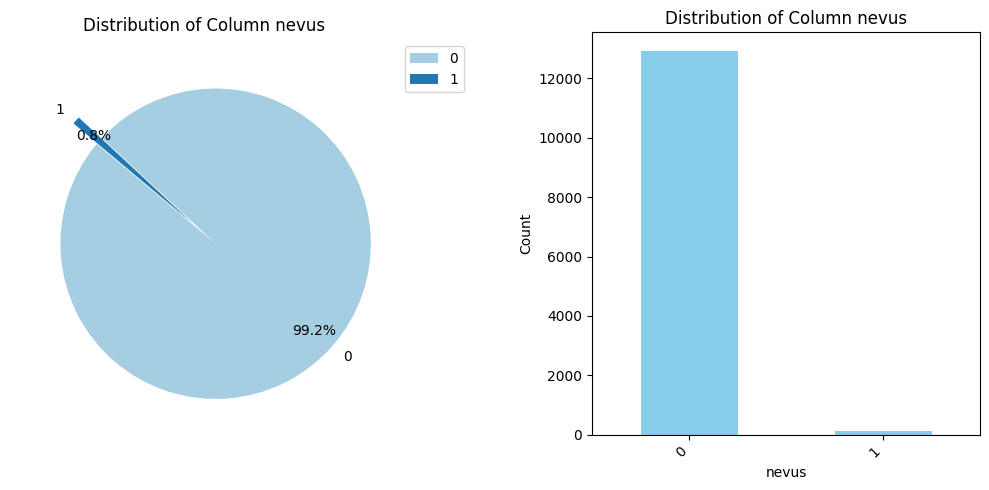

amd
0    0.982789
1    0.017211
Name: proportion, dtype: float64



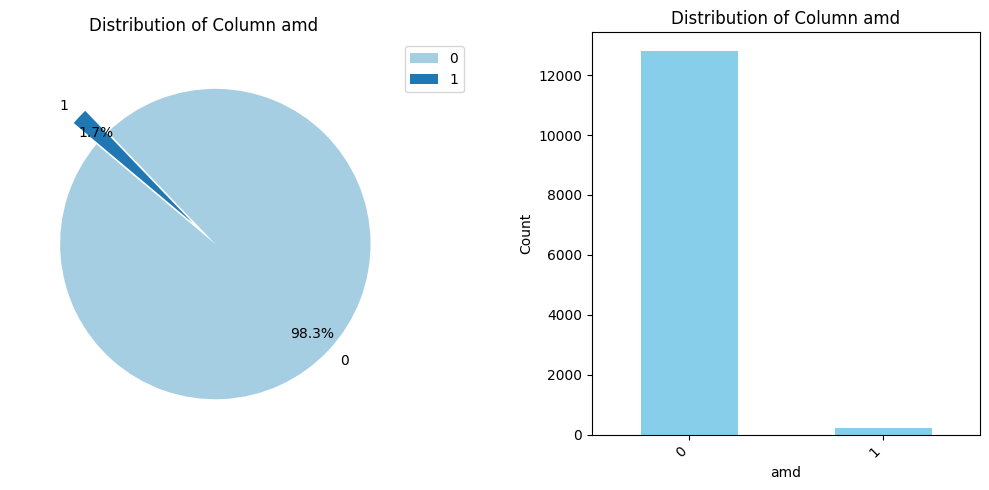

vascular_occlusion
0    0.993392
1    0.006608
Name: proportion, dtype: float64



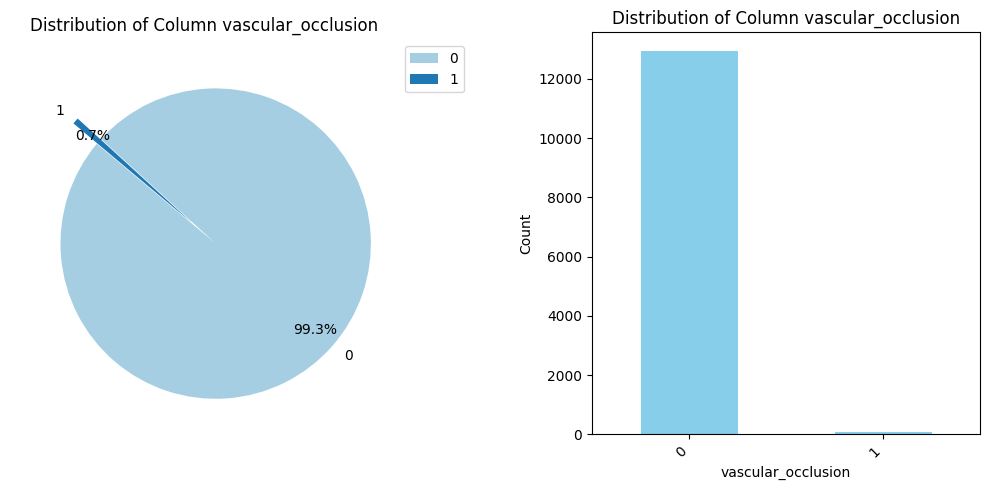

hypertensive_retinopathy
0    0.98302
1    0.01698
Name: proportion, dtype: float64



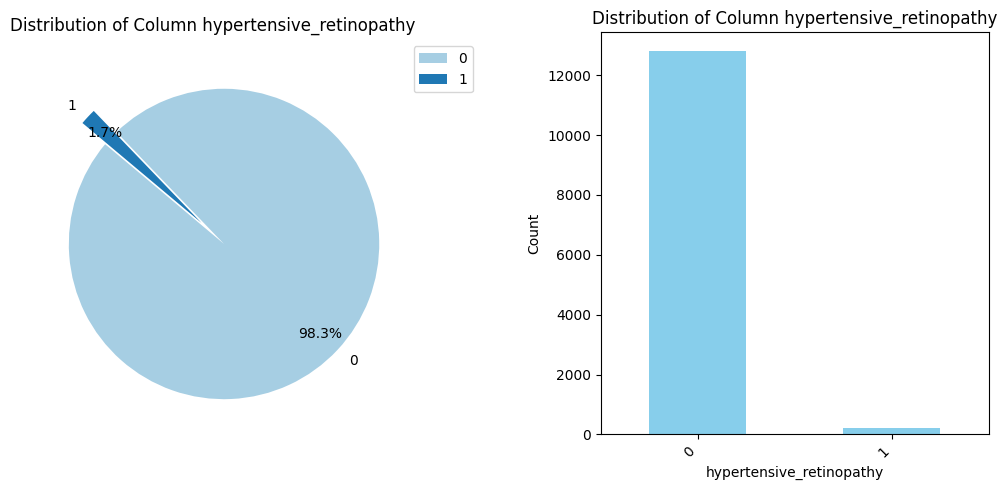

drusens
0    0.829197
1    0.170803
Name: proportion, dtype: float64



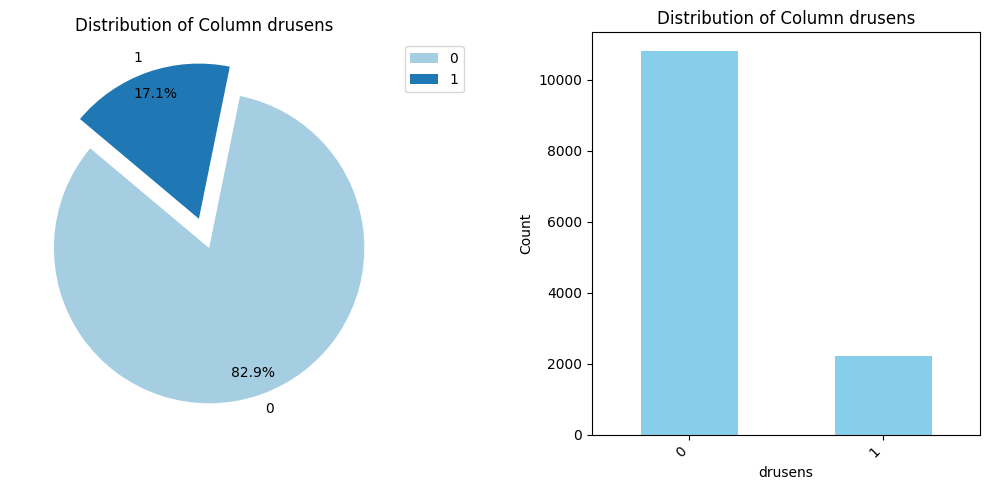

hemorrhage
0    0.994237
1    0.005763
Name: proportion, dtype: float64



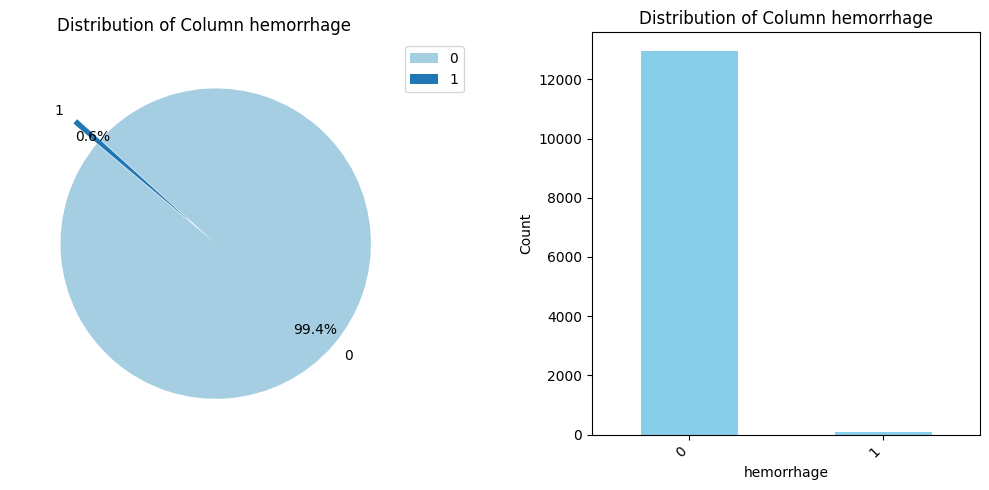

retinal_detachment
0    0.999539
1    0.000461
Name: proportion, dtype: float64



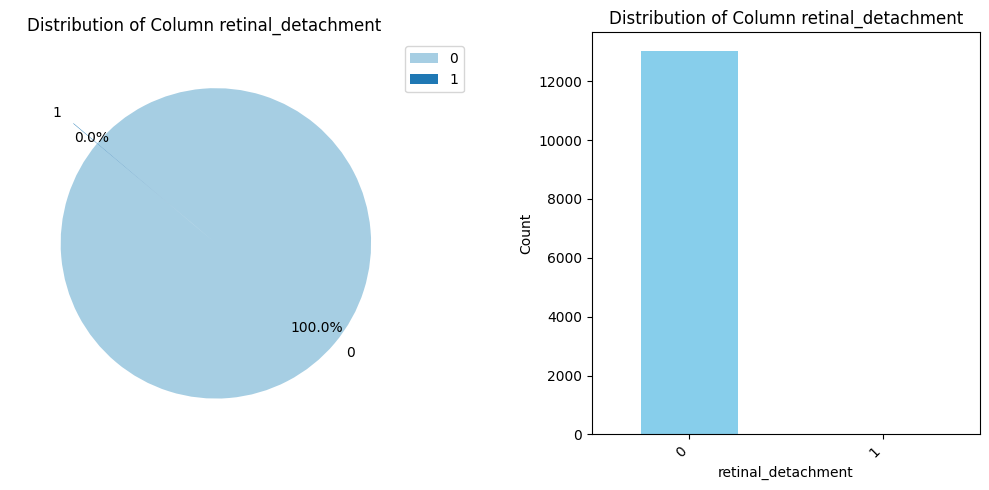

myopic_fundus
0    0.981483
1    0.018517
Name: proportion, dtype: float64



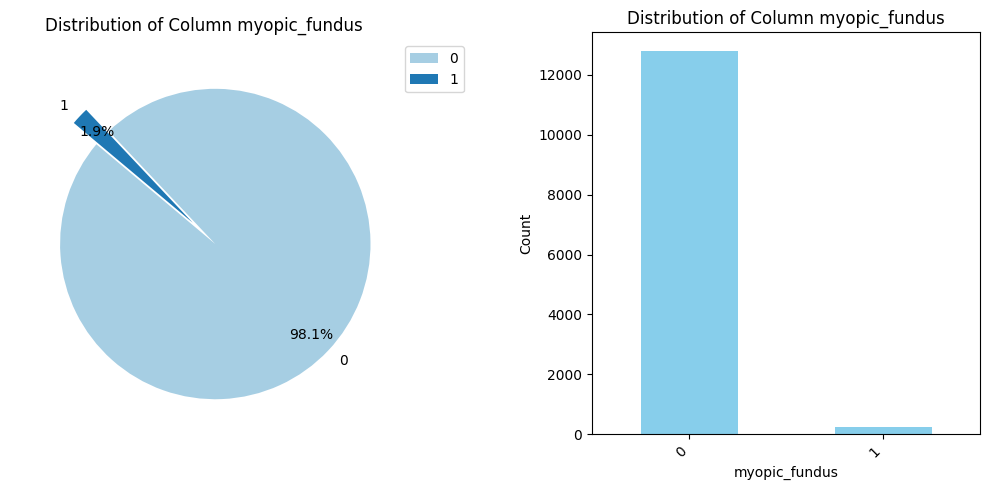

increased_cup_disc
0    0.800922
1    0.199078
Name: proportion, dtype: float64



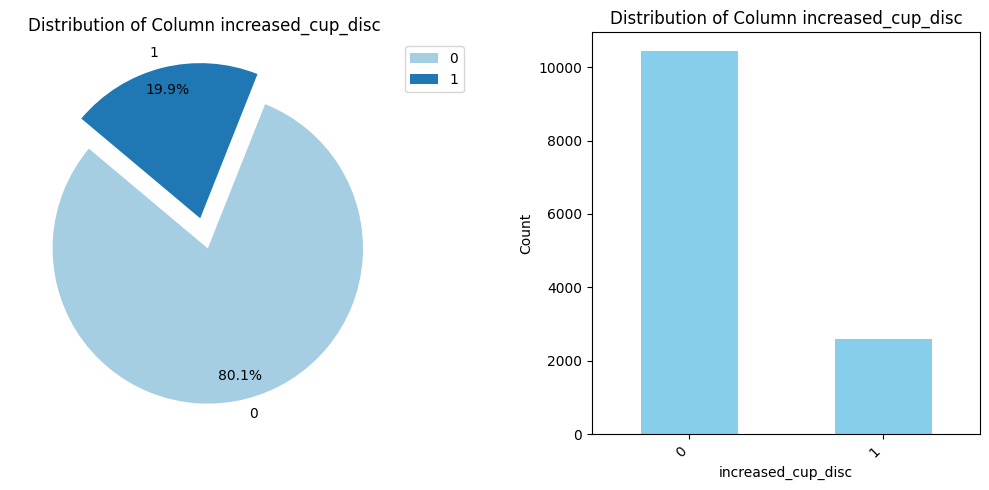

other
0    0.949827
1    0.050173
Name: proportion, dtype: float64



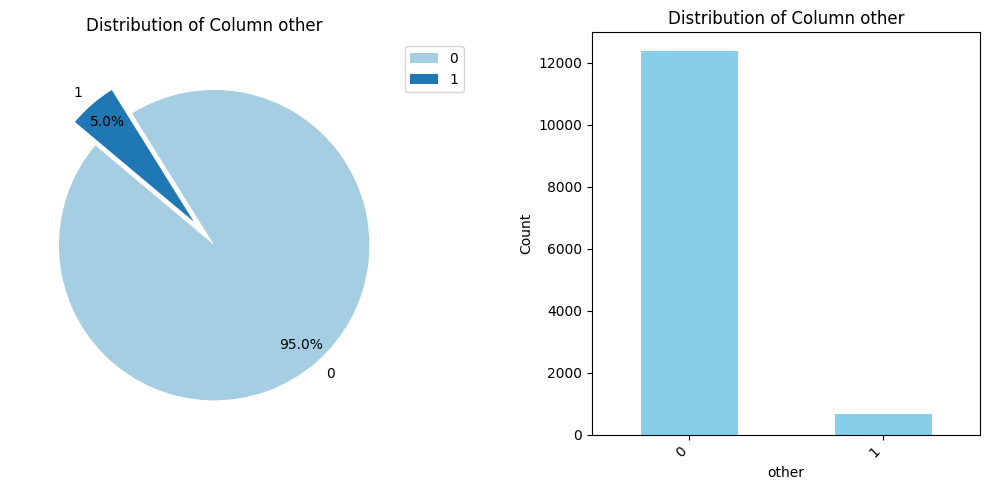

In [16]:
data3 = data2.copy()
data3.drop(columns=['patient_age','comorbidities','diabetes_time_y'],inplace=True)
for col in data3.columns:
    if data3[col].dtype == 'int64' or data3[col].dtype == 'float64':
        plot_categorical_column(data3,col)
    else:
        continue



In [17]:
def plot_categorical_columns(data3, n=10, categorical_columns=None, save=False):
    """    
    Generate pie charts and bar plots to visualize categorical columns in a Pandas DataFrame.

    Parameters:
    data3 (pandas.DataFrame): The DataFrame containing the categorical data.
    n (int): The maximum number of unique values for a column to be considered categorical. Default is 10.
    categorical_columns (list or None): A list of column names to be considered as categorical columns.
        If None, the function automatically identifies categorical columns based on the 'n' parameter.

    This function creates pie charts and bar plots for the specified categorical columns. The function
    enhances the quality of the plots by customizing colors, labels, and formatting.

    Args:
    data3 (pandas.DataFrame): The DataFrame containing the categorical data.
    n (int): The maximum number of unique values for a column to be considered categorical. Default is 10.
    categorical_columns (list or None): A list of column names to be considered as categorical columns.
        If None, the function automatically identifies categorical columns based on the 'n' parameter.

    Returns:
    None

    """
    if not(categorical_columns):
        # Identify categorical columns with unique values less than or equal to n
        categorical_columns = []
        for column in data3.columns:
            if data3[column].nunique() <= n:
                categorical_columns.append(column)
    
    # Create pie charts and bar plots for each categorical column
    for column in categorical_columns:
        print('#'*90)
        print('#'*40, f' {column} ', '#'*40)
        print('#'*90)
        
        plot_categorical_column(data3, column, save=save)
        

In [26]:
def plot_continuous(data2, column):
    """
    Plot the distribution of a continuous numerical variable in a DataFrame using a histogram.

    Parameters:
    - data2 (pandas.DataFrame): The DataFrame containing the data.
    - column (str): The name of the column to be visualized.

    Returns:
    None

    This function generates a histogram of the specified column's data distribution, calculates the mean of the data,
    and plots a vertical line representing the mean. It also displays descriptive statistics for the column.

    Example usage:
    plot_continuous(dataframe, 'column_name')

    Note:
    - The function uses Matplotlib for plotting and assumes that the necessary libraries (pandas, numpy, and Matplotlib)
      are imported and available in the current environment.

    """
    
        
    print(data2[column].describe())
    print()
    
    # Plot age distribution
    plt.figure(figsize=(20, 10))
    plt.hist(data2[column], bins=70, edgecolor='black', color='skyblue', alpha=0.7)

    # Calculating the mean
    mean_age = np.mean(data2['patient_age'])
    
    if column == 'patient_age':
        label = 'Age'
    else:
        label = column

    # Plotting the mean line
    plt.axvline(mean_age, color='red', linestyle='--', linewidth=3)
    plt.xlabel(label, fontdict={'fontsize': 20})
    plt.ylabel('Frequency', fontdict={'fontsize': 20})
    plt.title(f'{label} Distribution', fontdict={'fontsize': 25})
    plt.grid(True)

    # Adjusting tick labels and font sizes
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.show()

In [28]:
data2.info()

<class 'pandas.DataFrame'>
RangeIndex: 13015 entries, 0 to 13014
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   camera                    13015 non-null  str    
 1   patient_age               8669 non-null   float64
 2   comorbidities             6396 non-null   str    
 3   diabetes_time_y           1545 non-null   str    
 4   insuline                  1381 non-null   str    
 5   patient_sex               13015 non-null  int64  
 6   exam_eye                  13015 non-null  int64  
 7   diabetes                  13015 non-null  str    
 8   nationality               13015 non-null  str    
 9   optic_disc                13015 non-null  int64  
 10  vessels                   13015 non-null  int64  
 11  macula                    13015 non-null  int64  
 12  DR_SDRG                   13015 non-null  int64  
 13  DR_ICDR                   13015 non-null  int64  
 14  focus            

count    8669.000000
mean       57.911639
std        18.252587
min         5.000000
25%        47.000000
50%        61.000000
75%        71.000000
max        97.000000
Name: patient_age, dtype: float64



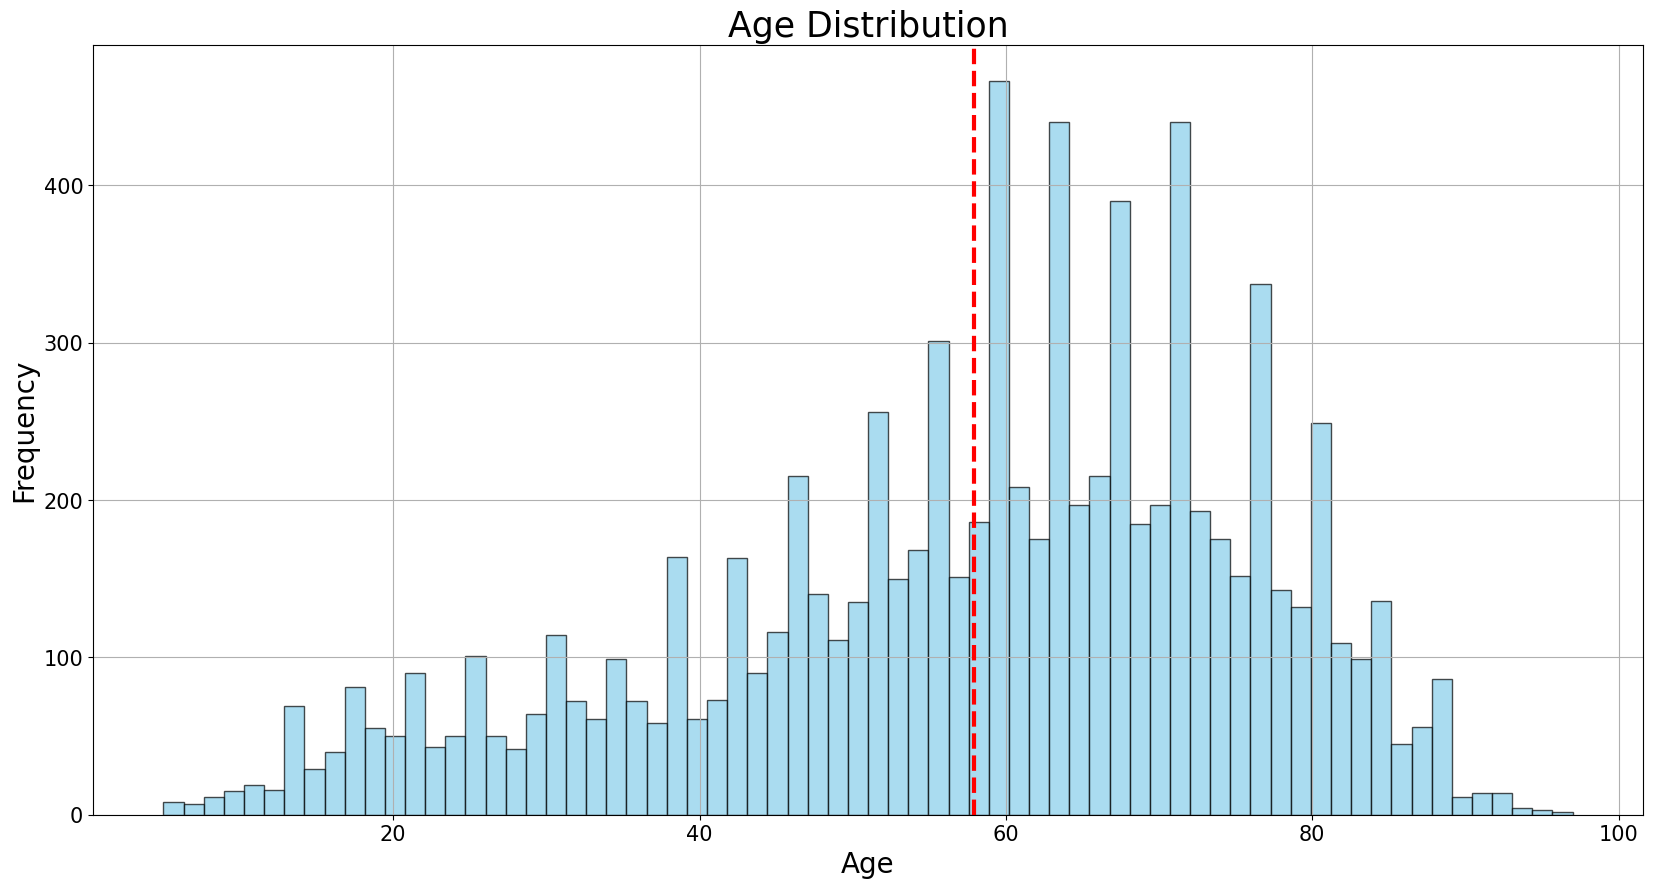

In [27]:
plot_continuous(data2,'patient_age')

In [35]:
def show_random_images(dataset_dir, image_folder, id_column, class_column, max_images_per_class, save=True):
    """
    Display random images from a dataset with their corresponding class labels.

    Parameters:
    dataset_dir (str): The directory where the dataset and labels are stored.
    image_folder (str): The subdirectory where the images are located.
    id_column (str): The column name containing unique image identifiers.
    class_column (str): The column name containing class labels.
    max_images_per_class (int): The maximum number of images to display per class.

    Example:
    show_random_images(
        dataset_dir="data/",
        image_folder="images",
        id_column="ID",
        class_column="Class",
        max_images_per_class=3
    )

    This example will display a random selection of images from the 'images' subdirectory of the 'data/' directory.
    It will use the 'ID' column as the unique image identifier and the 'Class' column for class labels.
    Up to 3 random images will be shown for each class.

    Note: Ensure that the required image files are present in the specified directory and subdirectory.
    """
    
    # Get the labels
    df = pd.read_csv(os.path.join(dataset_dir, "train.csv"))
    
    # Get the images:
    image_folder = os.path.join(dataset_dir, image_folder)
    
    grouped_df = df.groupby(class_column)
    sample_ids = []

    for _, group_df in grouped_df:
        num_images = min(len(group_df), max_images_per_class)
        image_ids = random.sample(group_df[id_column].tolist(), num_images)

        sample_ids.extend(image_ids)

    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12,10))

    for i, image_id in enumerate(sample_ids):
        image_path = os.path.join(image_folder, f'{image_id}.jpg')

        img = cv2.imread(image_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        subplot_row = i // 3
        subplot_col = i % 3

        ax = axes[subplot_row, subplot_col]

        class_value = df.loc[df[id_column] == image_id, class_column].values[0]
        file_name = os.path.basename(image_path)
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(f'Diagnosis: {class_value}')

    plt.tight_layout()
    if class_column == 'diabetic_retinopathy':
        column = 'Diabetic Retinopathy'
    else:
        column = class_column
    plt.suptitle(f'Sample Images with Class Labels for {column}', fontsize=16)
    
    if save:
        os.makedirs('Profile', exist_ok=True)
        plt.savefig(f'Profile/Sample images {column}')
    plt.show()

    

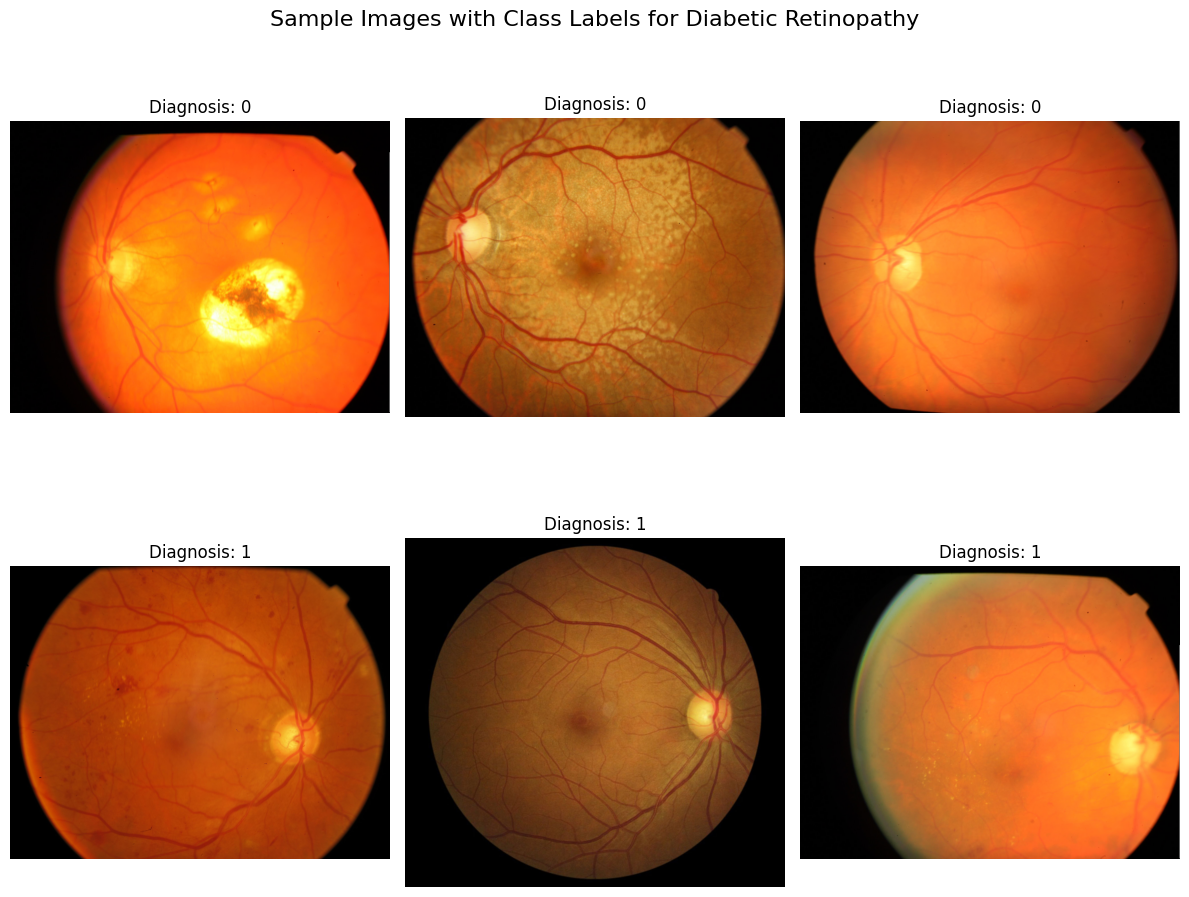

In [47]:
show_random_images(
    dataset_dir="../../Data/dataset_split/train",  # contains train.csv
    image_folder="images",
    id_column="image_id",
    class_column="diabetic_retinopathy",
    max_images_per_class=3
)

In [ ]:
def show_image(image, size=8):
    """
    Display a single image and its shape.

    Parameters:
    image (numpy.ndarray): The image to display.
    size (int, optional): The size of the displayed image. Defaults to 8.

    Example:
    image = skimage.io.imread("image.jpg")
    show_image(image, size=10)

    This example will display the specified image with a size of 10.

    Note: The image parameter should be a NumPy array representing the image.
    """
    print(f'The shape of the image is: {image.shape}')
    plt.figure(figsize=(size, size))
    plt.imshow(image)
    plt.show()



The shape of the image is: (874, 951, 3)


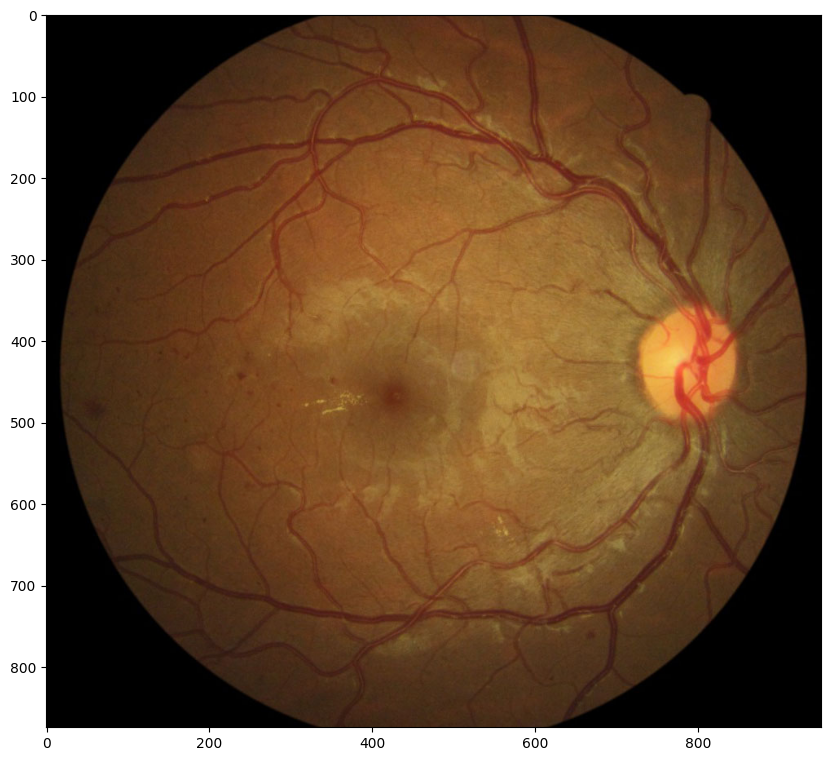

In [57]:
image = cv2.imread(r"../../Data\dataset_split\train\images\img00025.jpg",)
img = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
show_image(img,size=10)

In [58]:
def get_image_statistics(image_path):
    """
    Retrieve statistics for an image, including its dimensions and mean color values.

    Parameters:
    - image_path (str): The path to the image file.

    Returns:
    (height, width, mean_color_channels): A tuple containing the image's height, width, and mean color values for each channel (BGR).

    If the image cannot be read or doesn't exist, None is returned.

    Example usage:
    height, width, mean_b, mean_g, mean_r = get_image_statistics('image.jpg')

    Note:
    - This function uses the OpenCV (cv2) library to read the image.
    - The mean color values are calculated for each channel (Blue, Green, and Red) as BGR.

    """
    image = cv2.imread(image_path)
    if image is not None:
        height, width, _ = image.shape
        mean_colors = np.mean(image, axis=(0, 1))
        return height, width, *mean_colors
    return None


In [ ]:

imagepath = r"../../Data\dataset_split\train\images\img00025.jpg"
# get_image_statistics(imagepath)

(874,
 951,
 np.float64(28.349664450524198),
 np.float64(57.88872005139718),
 np.float64(90.61032587641095))

In [63]:
def get_image_statistics_df(image_directory):
    """
    Generate a DataFrame containing statistics for multiple images in a specified directory.

    Parameters:
    - image_directory (str): The path to the directory containing image files.

    Returns:
    (pandas.DataFrame): A DataFrame with columns "Height," "Width," "Mean_R," "Mean_G," "Mean_B," and "image_id."

    This function iterates through image files in the specified directory, calculates statistics for each image (dimensions
    and mean color values for each channel), and stores the results in a DataFrame. The "image_id" column contains the
    filenames of the processed images.

    Example usage:
    image_stats_dataframe = get_image_statistics_df('image_directory')

    Note:
    - This function depends on the get_image_statistics function for individual image statistics.
    - Only the first 51 images in the directory (as determined by the "i > 50" condition) are processed, and this condition
      can be adjusted as needed.
    """
    # Format to store the results
    columns = ["Height", "Width", "Mean_R", "Mean_G", "Mean_B", "image_id"]
    stats_dict = {'Height': [], 'Width': [], 'Mean_R': [], 'Mean_G': [], 'Mean_B': [], "image_id": []}
    
    for i, filename in enumerate(os.listdir(image_directory)):
        if i % 1000 == 0:
            print(f'Image #{i}...')

        if filename.endswith((".jpg", ".jpeg", ".png")):
            image_path = os.path.join(image_directory, filename)
            stats = get_image_statistics(image_path)
            height, width, mean_r, mean_g, mean_b = stats

            if stats is not None:
                for j, col in enumerate(columns):
                    if col == "image_id":
                        stats_dict[col].append(filename)
                    else:
                        stats_dict[col].append(stats[j])

    image_stats_df = pd.DataFrame(stats_dict)
    return image_stats_df


In [13]:
image_dir = "../../Data/dataset_split/train/images"

In [ ]:


# df_stats = get_image_statistics_df(image_dir)

# print(df_stats.head())
# print(df_stats.describe())

Image #0...
Image #1000...
Image #2000...
Image #3000...
Image #4000...
Image #5000...
Image #6000...
Image #7000...
Image #8000...
Image #9000...
Image #10000...
Image #11000...
Image #12000...
Image #13000...


In [73]:
# Generate a DataFrame containing statistics for multiple images in a specified directory.
df_stats.to_csv('statistical_train_images.csv', index=True)

print("File saved successfully!")

File saved successfully!


In [7]:
df_stats = pd.read_csv("statistical_train_images.csv")

In [8]:
def plot_image_statistics(image_stats_df):
    """
    Create histograms to visualize and analyze image statistics.

    Parameters:
    - image_stats_df (pandas.DataFrame): DataFrame containing image statistics, including "Height," "Width," "Mean_R,"
      "Mean_G," and "Mean_B."

    Returns:
    None

    This function generates histograms for image statistics, providing insights into the distribution of image dimensions
    (height and width) and the mean color values in the Red (R), Green (G), and Blue (B) channels.

    Example usage:
    plot_image_statistics(image_stats_df)

    Note:
    - The input DataFrame should have the specified columns for image statistics.
    - The function uses Matplotlib for plotting and assumes that the necessary libraries (pandas and Matplotlib) are
      imported and available in the current environment.
    """
    
    print('Statistics: ')
    print(image_stats_df.describe())
    
    # Plot histograms
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(14, 8))
    fig.suptitle('Image Statistics Histograms', fontsize=16)

    # Plot Height histogram
    axes[0, 0].hist(image_stats_df['Height'], bins=10, color='skyblue', alpha=0.7)
    axes[0, 0].set_title('Height')
    axes[0, 0].set_xlabel('Height')
    axes[0, 0].set_ylabel('Frequency')

    # Plot Width histogram
    axes[0, 1].hist(image_stats_df['Width'], bins=10, color='lightgreen', alpha=0.7)
    axes[0, 1].set_title('Width')
    axes[0, 1].set_xlabel('Width')
    axes[0, 1].set_ylabel('Frequency')

    # Separate the RGB channels for Mean_R, Mean_G, and Mean_B
    # Plot Mean_R histogram
    axes[0, 2].hist(image_stats_df['Mean_R'], bins=10, color='salmon', alpha=0.7, label='R')
    axes[0, 2].hist(image_stats_df['Mean_G'], bins=10, color='lightgreen', alpha=0.7, label='G')
    axes[0, 2].hist(image_stats_df['Mean_B'], bins=10, color='dodgerblue', alpha=0.7, label='B')
    axes[0, 2].set_title('RGB Mean')
    axes[0, 2].set_xlabel('RGB Mean')
    axes[0, 2].set_ylabel('Frequency')
    axes[0, 2].legend()

    # Plot Mean_R histogram
    axes[1, 0].hist(image_stats_df['Mean_R'], bins=10, color='salmon', alpha=0.7)
    axes[1, 0].set_title('Mean Red')
    axes[1, 0].set_xlabel('Mean Red')
    axes[1, 0].set_ylabel('Frequency')

    # Plot Mean_G histogram
    axes[1, 1].hist(image_stats_df['Mean_G'], bins=10, color='lightgreen', alpha=0.7)
    axes[1, 1].set_title('Mean Green')
    axes[1, 1].set_xlabel('Mean Green')
    axes[1, 1].set_ylabel('Frequency')

    # Plot Mean_B histogram
    axes[1, 2].hist(image_stats_df['Mean_B'], bins=10, color='dodgerblue', alpha=0.7)
    axes[1, 2].set_title('Mean Blue')
    axes[1, 2].set_xlabel('Mean Blue')
    axes[1, 2].set_ylabel('Frequency')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

Statistics: 
         Unnamed: 0        Height         Width        Mean_R        Mean_G  \
count  13015.000000  13015.000000  13015.000000  13015.000000  13015.000000   
mean    6507.000000   2044.424587   2634.881905     28.101161     76.073905   
std     3757.251212    249.803536    352.234065     15.842471     20.801206   
min        0.000000    874.000000    951.000000      0.655296     14.730580   
25%     3253.500000   1880.000000   2390.000000     16.162622     61.601819   
50%     6507.000000   2056.000000   2672.000000     25.637978     75.227198   
75%     9760.500000   2304.000000   2984.000000     37.506887     89.468721   
max    13014.000000   2304.000000   2984.000000    113.492615    163.723054   

             Mean_B  
count  13015.000000  
mean     150.344164  
std       28.042996  
min       46.179830  
25%      133.676533  
50%      152.439798  
75%      170.095406  
max      215.899511  


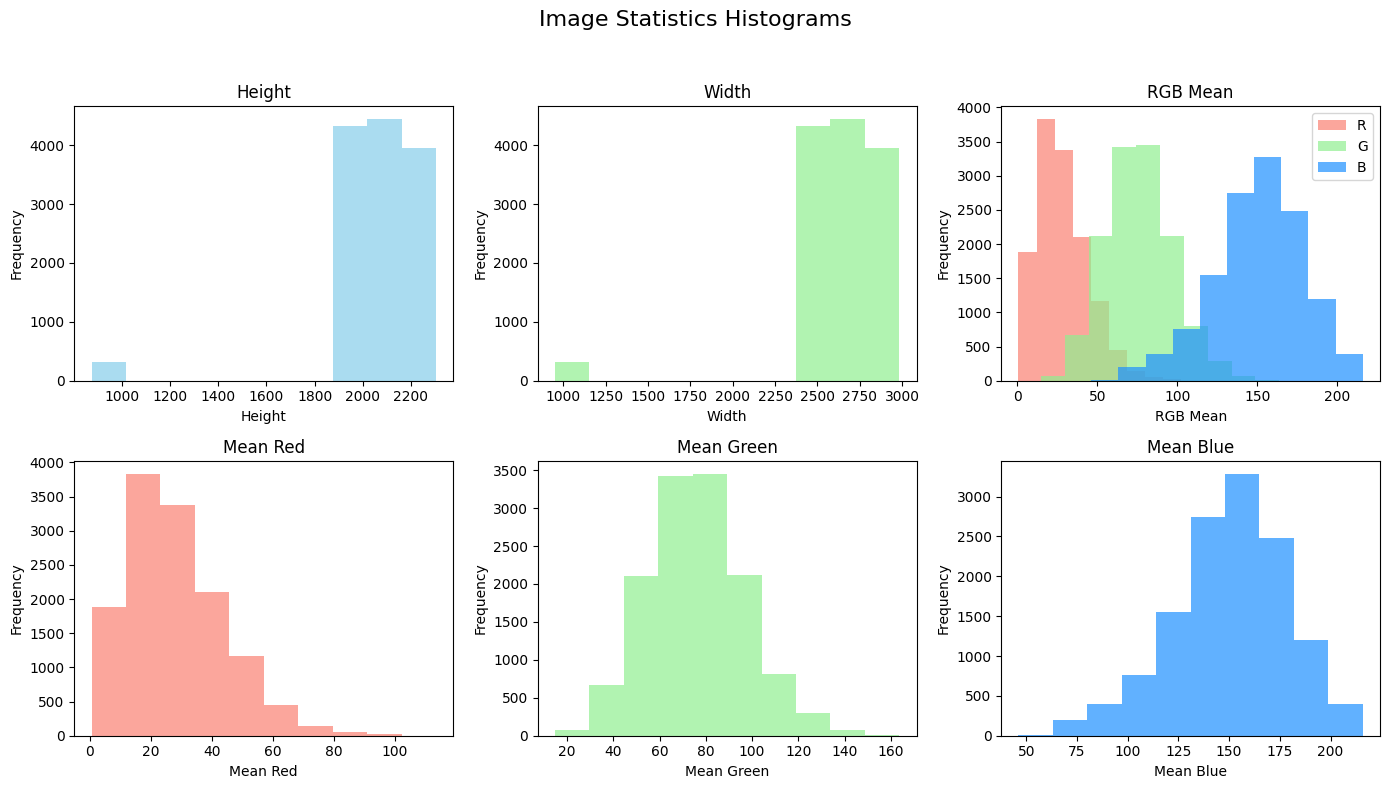

In [9]:
plot_image_statistics(df_stats)

In [10]:
def calculate_normalization_values(image_folder):
    # Initialize empty lists to store pixel values
    mean_values = [0, 0, 0]
    std_values = [0, 0, 0]

    # Create a transform to convert images to tensors
    transform = transforms.ToTensor()

    # Iterate through the images in the folder and accumulate pixel values
    image_paths = [os.path.join(image_folder, filename) for filename in os.listdir(image_folder)]

    for image_path in image_paths:
        if not(image_path.endswith('.jpg')):
            continue
        image = Image.open(image_path).convert('RGB')
        image_tensor = transform(image)
        for i in range(3):  # Channels (R, G, B)
            mean_values[i] += image_tensor[i, :, :].mean().item()
            std_values[i] += image_tensor[i, :, :].std().item()

    # Calculate the mean and standard deviation
    num_images = len(image_paths)
    mean_values = [m / num_images for m in mean_values]
    std_values = [s / num_images for s in std_values]

    print("Mean values (R, G, B):", mean_values)
    print("Standard deviation (R, G, B):", std_values)



In [11]:
from PIL import Image
from torchvision import transforms

In [14]:
calculate_normalization_values(image_dir)

Mean values (R, G, B): [0.5895849683870502, 0.2983290482886333, 0.11020063914410853]
Standard deviation (R, G, B): [0.28518929768023105, 0.1587298774156509, 0.06984896787005408]
